In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"beyzahiz","key":"80dc9015b76a77a6a15c99f1d215774b"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                          Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          11131        270                1  
algozee/teenager-menthal-healy                                 Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           2315         54                1  
algozee/healthcare-disease-prediction-dataset                  Healthcare Disease Prediction Dataset                    19282  2026-04-10 18:13:49.690000            715         31        0.9411765  
sumea

In [5]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip brain-tumor-mri-dataset.zip

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  inflatin

In [6]:
!ls

brain-tumor-mri-dataset.zip  kaggle.json  sample_data  Testing	Training


In [7]:
!ls Training

glioma	meningioma  notumor  pituitary


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = "Training"
test_dir = "Testing"

#CLAHE
#Görüntüdeki en parlak ve en koyu noktaları alıp tüm resme yayar. Ama bu bazen görüntüyü çok gürültülü (parazitli) yapar.
#Görüntünün karanlık ve aydınlık bölgelerini dengeleyerek detayları ortaya çıkaran bir teknik.
#

def medical_preprocessing(img):
    img = img.astype('uint8') #Görseli uint8 formatına al. CLAHE sadece 0-255 arası tamsayılarla çalışır
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) # CLAHE Uygula
    # clipLimit=2.0: Kontrastı ne kadar sınırlayacağı (2.0 genelde iyidir)
    # tileGridSize=(8,8): Görüntüyü 8x8'lik küçük parçalara böler
    for i in range(3): # Renkli kanallara ayrı ayrı uygula
        img[:,:,i] = clahe.apply(img[:,:,i])
    return img.astype('float32') # Model float bekler

train_datagen = ImageDataGenerator(
    preprocessing_function=medical_preprocessing, # Rescale SİLİNDİ, bu EKLENDİ
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=medical_preprocessing)

train_generator = train_datagen.flow_from_directory( #bu fonksiyon klasörleri okur, görselleri yükler, label üretir
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [9]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [10]:
#EfficentNet Modeli

import cv2
from tensorflow.keras import layers,models
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False, #sınıflandırma katmanları modelin dışında bırakılır yani model özellik çıkarıcı olarak kullanılır.
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

# SADECE ÜST KATMANLARI EĞİT
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Sadece üst katmanlar eğitiliyor...")
model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

# FİNE-TUNİNG
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau( #model gelişmekte zorlandığında öğrenme hızını %80 oranında azaltarak daha hassas öğrenmesini sağlıyor
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

#Fine-tuning yaparken çok düşük bir learning rate (1e-5) seçilir
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning aşamasına geçiliyor...")
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=test_generator,
    callbacks=[early_stop, reduce_lr]
)



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Sadece üst katmanlar eğitiliyor...
Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 130s 567ms/step - accuracy: 0.7804 - loss: 0.5721 - val_accuracy: 0.8069 - val_loss: 0.5669
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 91s 522ms/step - accuracy: 0.8561 - loss: 0.3826 - val_accuracy: 0.7987 - val_loss: 0.5708
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 92s 522ms/step - accuracy: 0.8680 - loss: 0.3402 - val_accuracy: 0.8238 - val_loss: 0.4533
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 91s 516ms/step - accuracy: 0.8841 - loss: 0.3104 - val_accuracy: 0.8456 - val_loss: 0.4498
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 91s 518ms/step - accuracy: 0.8920 - loss: 0.2848 - val_accuracy: 0.8763 - val_loss: 0.3863
Fine-tuning aşamasına geçiliyor...
Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 128s 567ms/step - accuracy: 0.8330 - loss: 0.4536 - val_accuracy: 0.8487 - val_loss: 0.4392 - learning_rate: 1.0000e-05
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 92s 527ms/step - accuracy: 0

In [11]:
model.save("mri_model.keras")

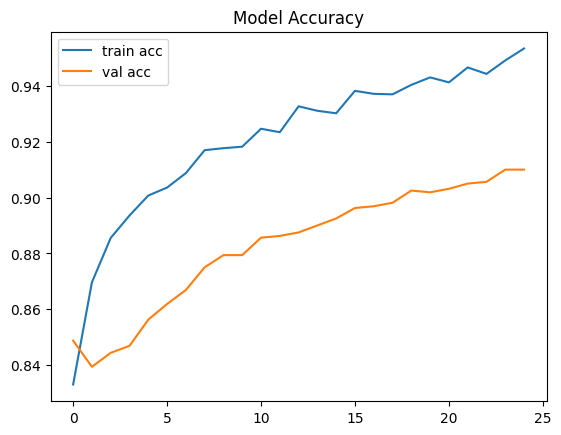

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()


Analiz ediliyor: Testing/glioma/Te-gl_393.jpg
Katman: top_conv


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


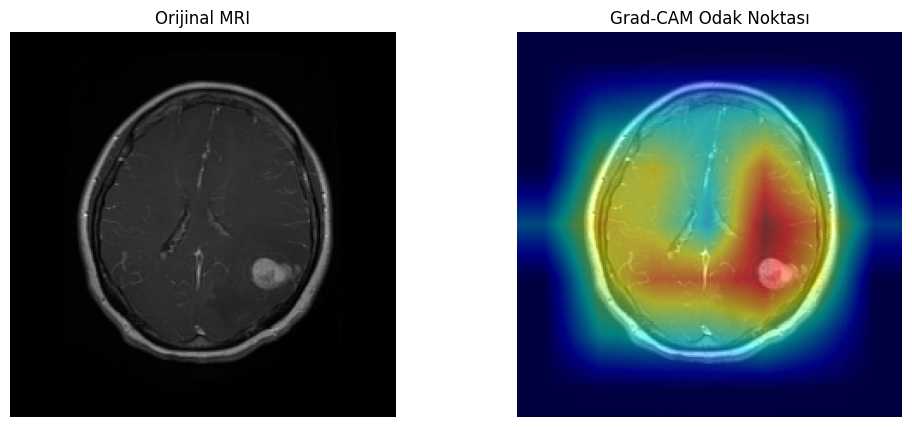

Katman: block7a_project_conv


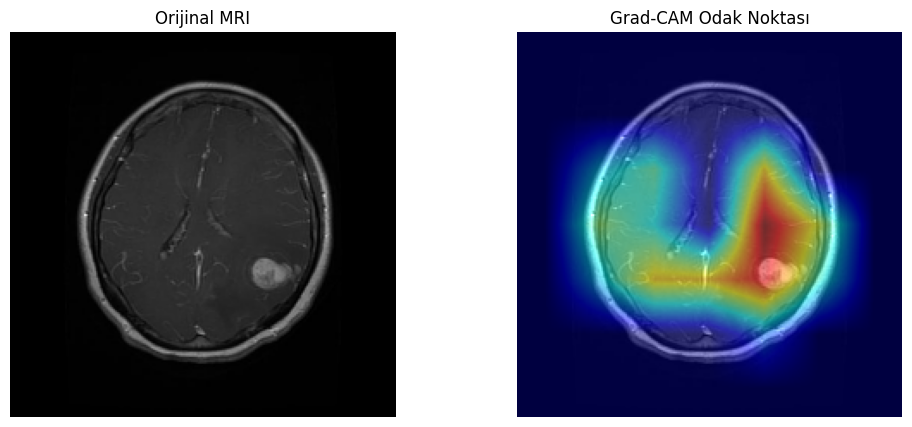

In [15]:
# 1. Gelişmiş Isı Haritası Fonksiyonu (Gürültü Filtrelemeli)
def load_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = medical_preprocessing(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    try:
        last_conv_layer = model.get_layer(last_conv_layer_name)
    except ValueError:
        base_model = model.layers[0]
        last_conv_layer = base_model.get_layer(last_conv_layer_name)
        model = base_model

    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = tf.gather(predictions[0], class_idx)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # İyileştirme: Negatif değerleri at ve normalize et
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)

    # Yeni: %20'nin altındaki zayıf sinyalleri temizle (Thresholding)
    # Bu, odaklanmanın daha "keskin" olmasını sağlar.
    heatmap = np.where(heatmap > 0.2, heatmap, 0)

    return heatmap

# 2. Yan Yana Karşılaştırmalı Görselleştirme
def display_results(img_path, heatmap, alpha=0.5):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    # Isı haritasını hazırla
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Orijinal resimle birleştir
    superimposed_img = cv2.addWeighted(img, 1, heatmap_color, alpha, 0)

    # Görüntüleri yan yana koy (Doktor sunumu gibi)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Orijinal MRI")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Odak Noktası")
    plt.axis('off')

    plt.show()

# 3. KATMAN TESTİ VE ÇOKLU GÖRSELLEŞTİRME
# 'top_conv' yerine 'block7a_project_conv' deneyerek hassasiyeti kontrol ediyoruz
layers_to_try = ["top_conv", "block7a_project_conv"]
test_images = [
    "Testing/glioma/Te-gl_393.jpg",
    "Testing/pituitary/Te-pi_0010.jpg" # Farklı bir sınıf da ekle
]

for img_p in test_images:
    if os.path.exists(img_p):
        print(f"\nAnaliz ediliyor: {img_p}")
        img_arr = load_image(img_p)

        for lyr in layers_to_try:
            print(f"Katman: {lyr}")
            h_map = make_gradcam_heatmap(img_arr, model, lyr)
            display_results(img_p, h_map)

In [ ]:
# Test
img = load_image(img_path)

# Fonksiyon artık Sequential olduğunu kendisi anlayacaktır
heatmap = make_gradcam_heatmap(
    img,
    model, # Direkt ana modeli gönder
    last_conv_layer_name="top_conv"
)

display_gradcam(img_path, heatmap)